<img src="ost_logo.png" width="240" height="240" align="right"/>
<div style="text-align: left"> <b> Machine Learning </b> <br> MSE FTP MachLe <br> 
<a href="mailto:christoph.wuersch@ost.ch"> Christoph Würsch </a> </div>

# ML08: A4 SVM with polynomial and linear kernel

MSE, FTP_MachLe, WÜRC


Whenever you have a model that is represented with inner products, you can plug in a kernel function. For instance, a linear kernel is the same as applying linear transformations to feature space. And, in this case, it’s the same as a support vector classifier, because the decision boundary is linear.
- With __polynomial kernels__, you’re projecting the original feature space into a polynomial feature space. So the decision boundary that separates the classes is defined with a higher order polynomial.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_random_dataset(size):
    """ Generate a random dataset and that follows a quadratic  distribution
    """
    x = []
    y = []
    target = []
    for i in range(size):
        # class zero
        x.append(np.round(random.uniform(0, 2.5), 1))
        y.append(np.round(random.uniform(0, 20), 1))
        target.append(0)
        # class one
        x.append(np.round(random.uniform(1, 5), 2))
        y.append(np.round(random.uniform(20, 25), 2))
        target.append(1)
        x.append(np.round(random.uniform(3, 5), 2))
        y.append(np.round(random.uniform(5, 25), 2))
        target.append(1)
    df_x = pd.DataFrame(data=x)
    df_y = pd.DataFrame(data=y)
    df_target = pd.DataFrame(data=target)
    data_frame = pd.concat([df_x, df_y], ignore_index=True, axis=1)
    data_frame = pd.concat([data_frame, df_target], ignore_index=True, axis=1)
    data_frame.columns = ['x', 'y', 'target']
    return data_frame



In [2]:
# Generate dataset
size = 100
dataset = generate_random_dataset(size)

X = dataset[['x', 'y']]
y = dataset['target']
dataset.to_csv('dataset.csv')


In [3]:
dataset.head()

,x,y,target
0,1.00,7.90,0
1,4.63,20.53,1
2,3.32,18.03,1
3,1.10,7.50,0
4,3.79,22.84,1


### (a) Split the data in 70% training  and 30% test data
 using `train_test_split` from `sklearn.model_selection`.

In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### (b) Plot the training data as scatter plot using different colors for both classes.

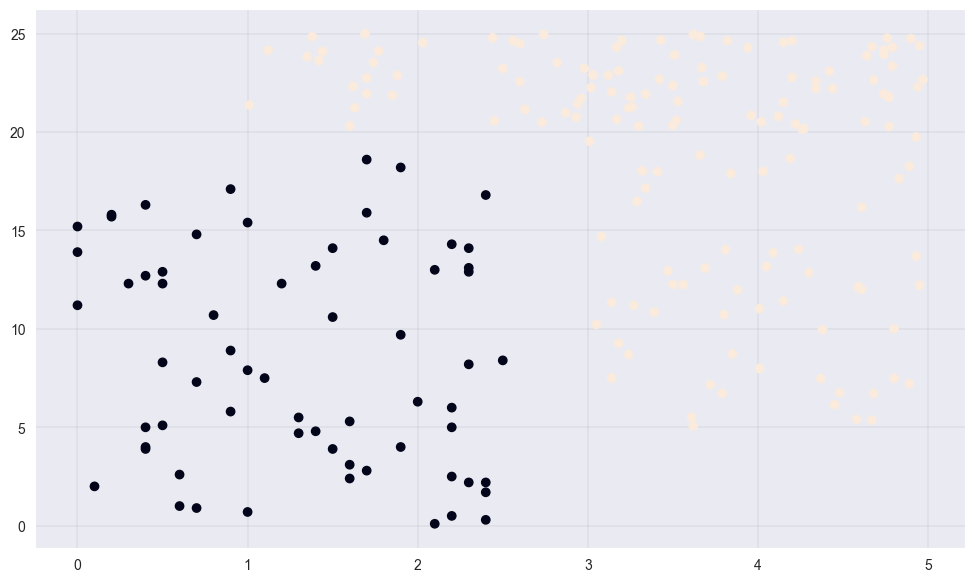

In [5]:
# Plotting the training set
fig, ax = plt.subplots(figsize=(12, 7))
# adding major gridlines
ax.grid(color='grey', linestyle='-', linewidth=0.25, alpha=0.5)

ax.scatter(x_train.x, x_train.y, c=y_train)

plt.show()

### (c) Fit an SVM with a second-degree polynomial kernel using $\gamma=0.1$ and $C=1$

There’s a little space between the two groups of data points. But closer to the center, it’s not clear which data point belongs to which class.
A quadratic curve might be a good candidate to separate these classes. 
__So let’s fit an SVM with a second-degree polynomial kernel.__

In [6]:
from sklearn import svm
model = svm.SVC(kernel='poly', degree=2,C=1,gamma=0.10)
model.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### (d) Plot the margins and decision boundary of the classifier
- use the function `PlotDecisionBoundary(model,X,y)`
- The input arguments the instance of the trained model, the 2D array of the featues `X` and the 1D array of the target `y`.

In [7]:
# Plot the dataset
def PlotDecisionBoundary(model, X,y):

    #plot decision boundary for model in case of 2D feature space
    x1=X[:,0]
    x2=X[:,1]
    # Create grid to evaluate model
    xx = np.linspace(min(x1), max(x1), len(x1))
    yy = np.linspace(min(x1), max(x2), len(x2))
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    train_size = len(x1)

    # Assigning different colors to the classes
    colors = y
    colors = np.where(colors == 1, '#8C7298', '#4786D1')

    # Get the separating hyperplane
    Z = model.decision_function(xy).reshape(XX.shape)

    fig, ax = plt.subplots(figsize=(12, 7))
    ax.scatter(x1, x2, c=colors)

    # Draw the decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

    # Highlight support vectors with a circle around them
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')
    plt.title('g=%f | C=%f' % (model.gamma,model.C))
    #plt.savefig('PolynomialKernel.pdf')
    plt.show()

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


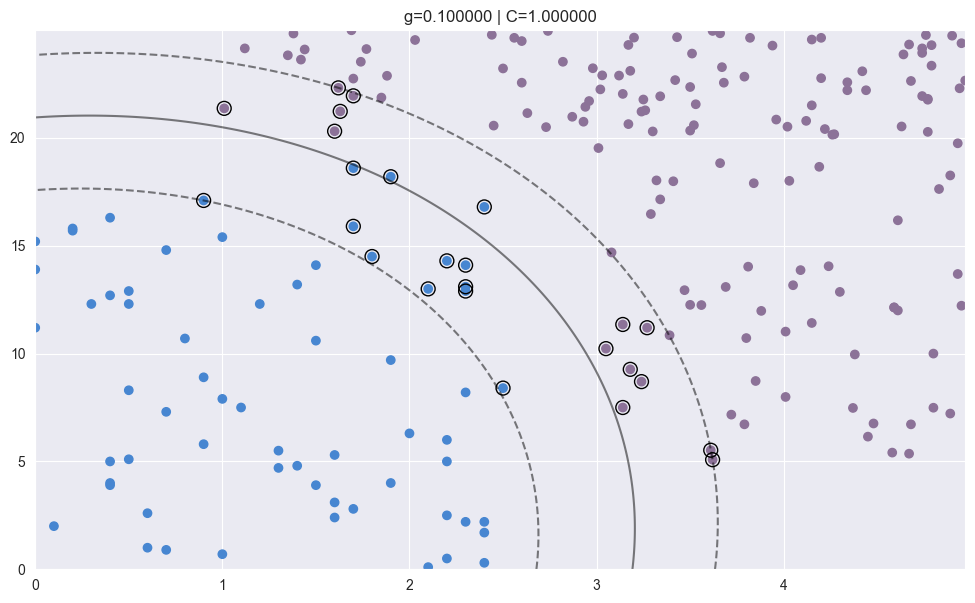

In [8]:
PlotDecisionBoundary(model, x_train.values,y_train)

### (e) Vary the hyperparameter $\gamma$ logarithmically in the range from $10^{-2}$ to $10^{+2}$ in 5 steps. 
 - set $C=1$ and plot for each value of the parameter $\gamma$ the decision boundary and the marigns.

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


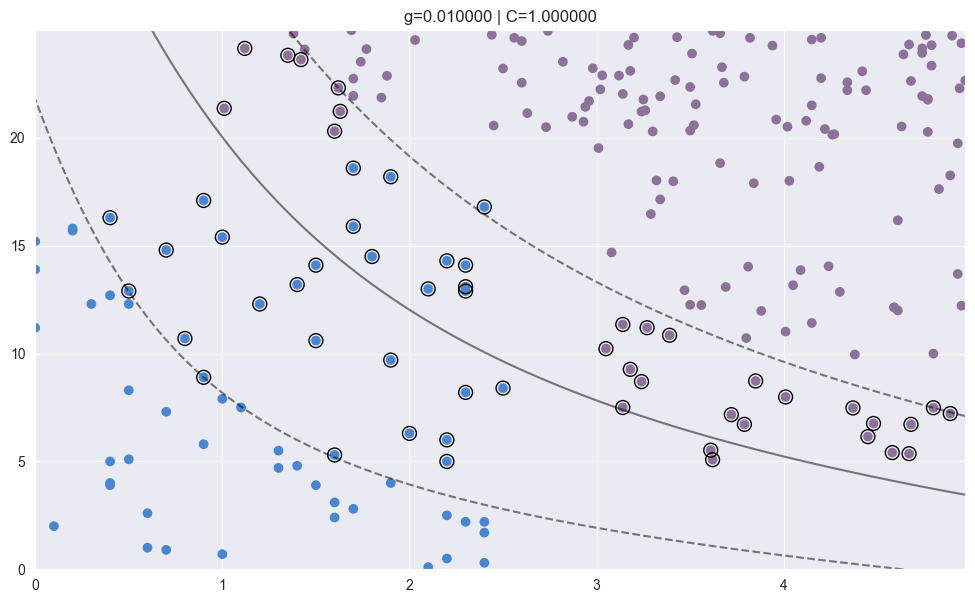

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


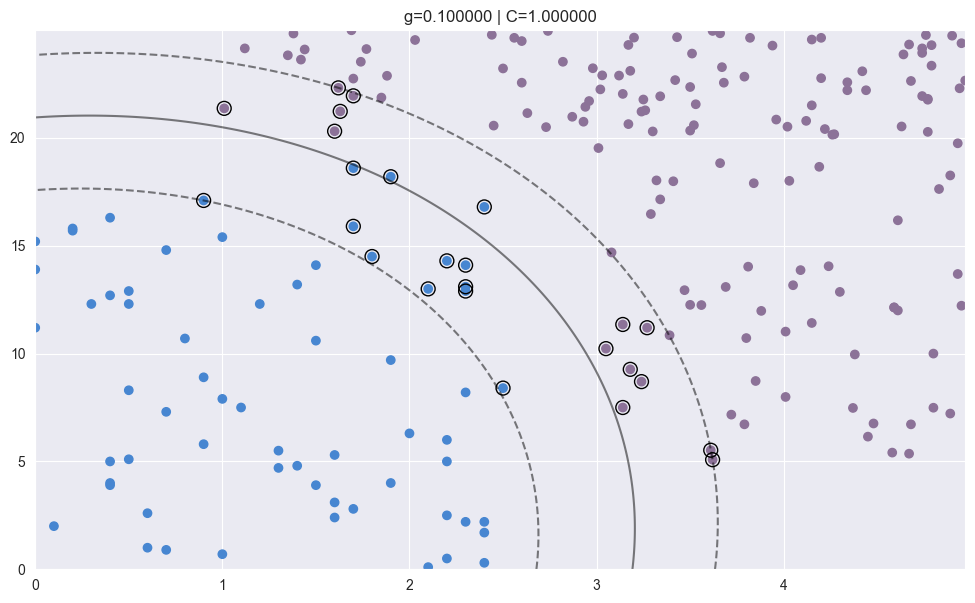

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


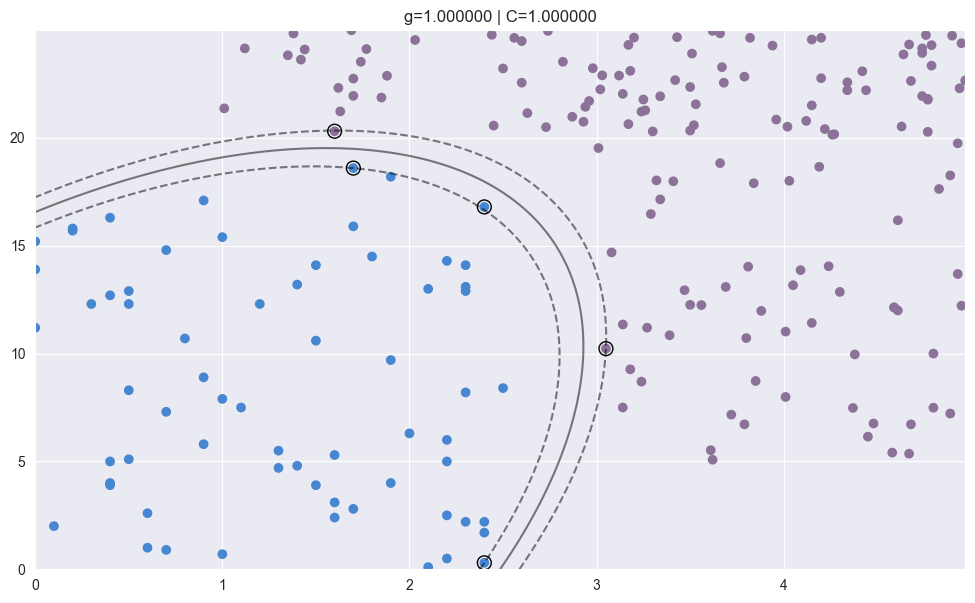

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


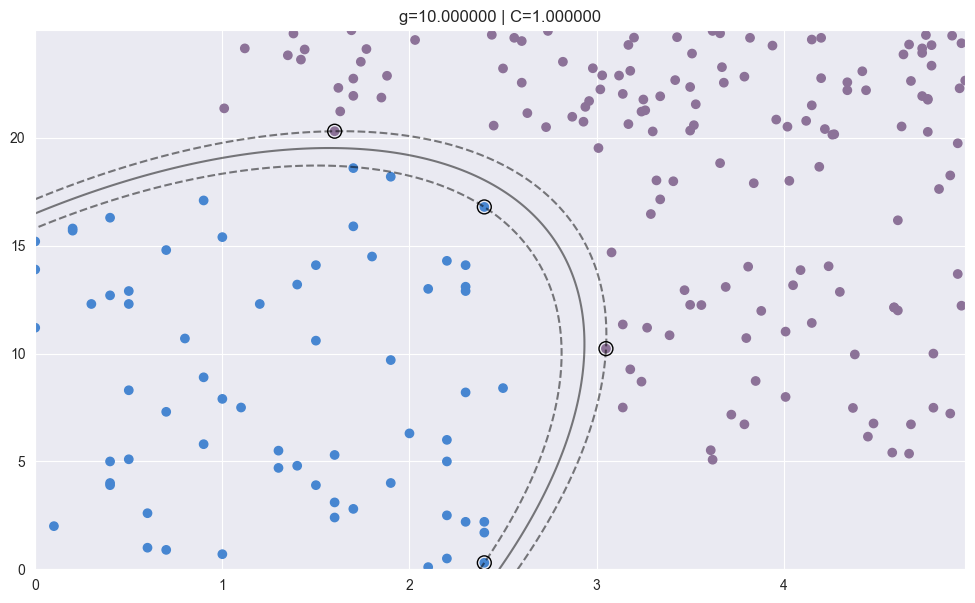

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


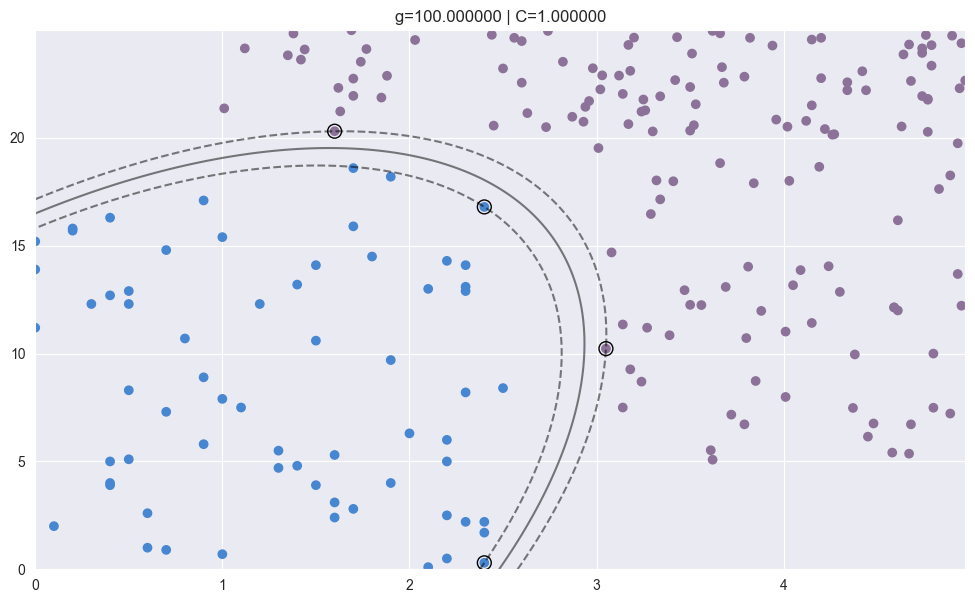

In [9]:
gammaList=np.logspace(-2,2,5)

for gamma in gammaList:
    model = svm.SVC(kernel='poly', degree=2, C=1, gamma=gamma)
    model.fit(x_train, y_train)
    PlotDecisionBoundary(model, x_train.values,y_train)
    

### (f) Vary the hyperparameter $C$ logarithmically in the range from $10^{0}$ to $10^{4}$ in 5 steps. 
 - set $\gamma=0.01$ and plot for each value of the parameter $C$ the decision boundary and the marigns.

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


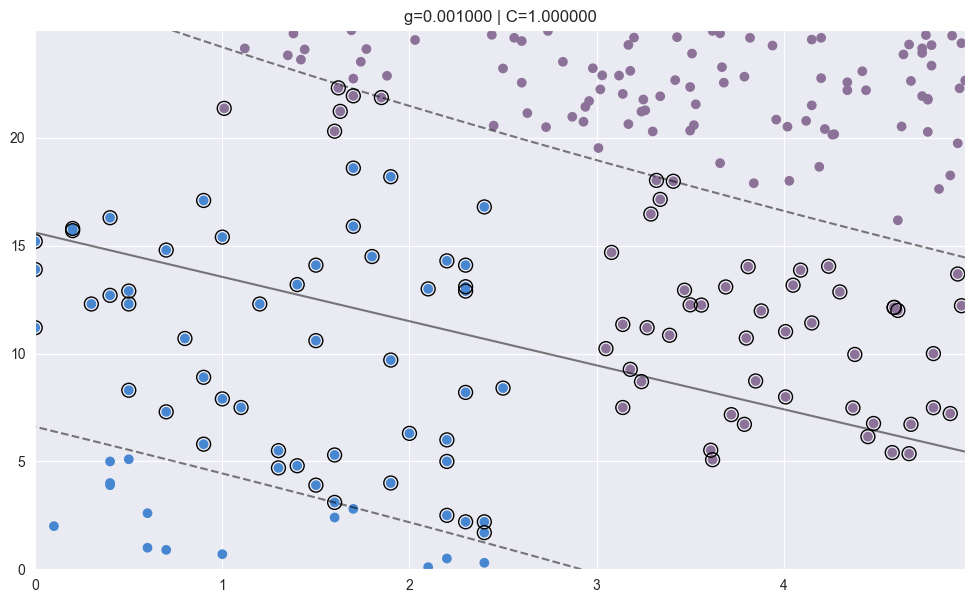

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


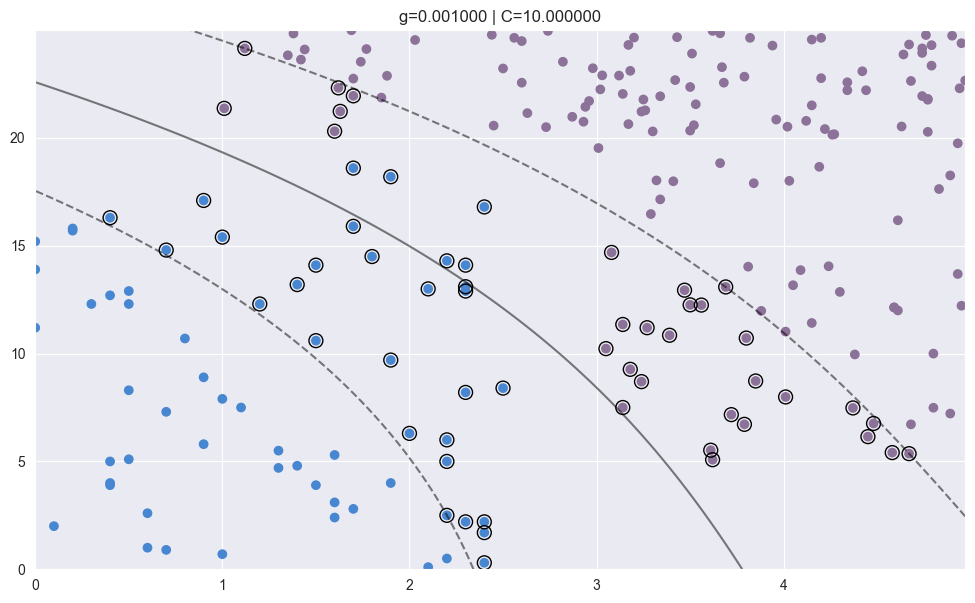

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


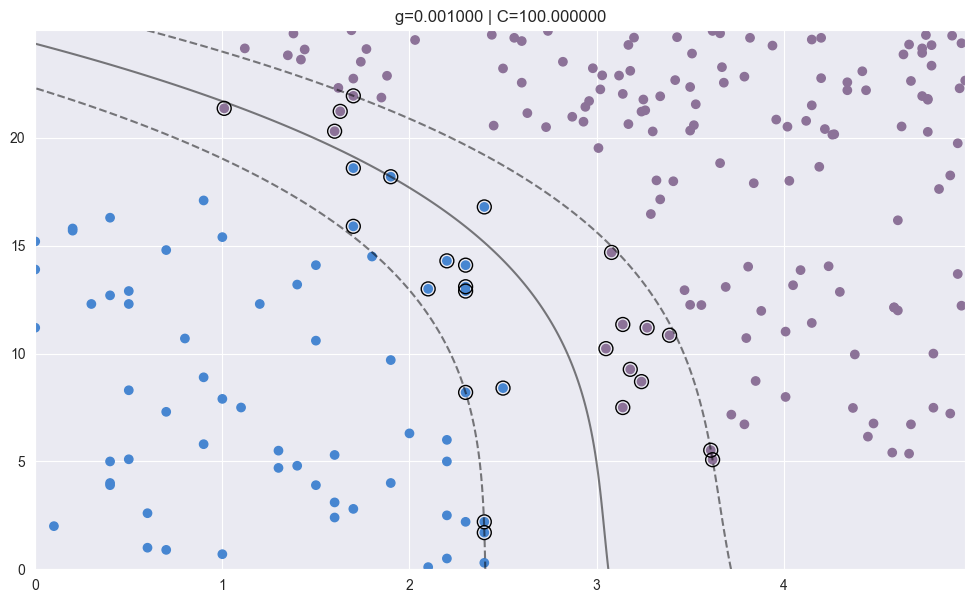

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


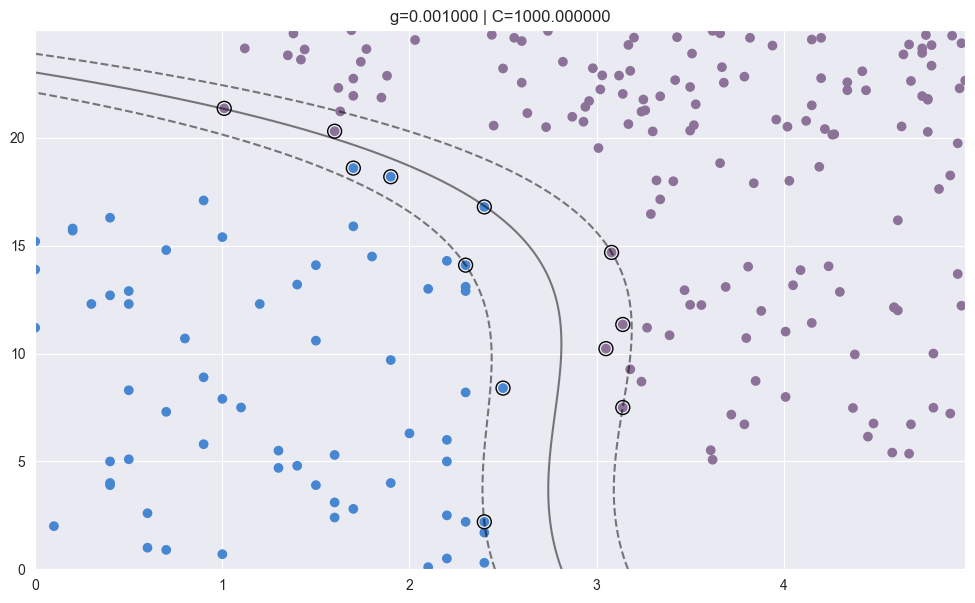

/Users/marbetschar/Development/zhaw/MachLe/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


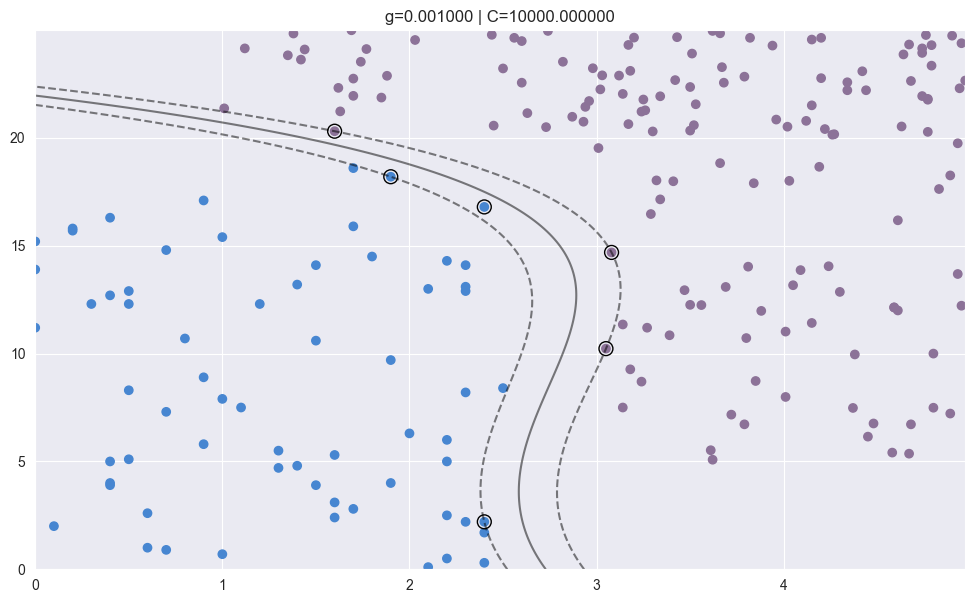

In [10]:
gamma=0.001
CList=np.logspace(0,4,5)

for C in CList:
    model = svm.SVC(kernel='rbf',C=C,gamma=gamma)
    model.fit(x_train, y_train)
    PlotDecisionBoundary(model, x_train.values,y_train)